# Tutorial 4: CostGrow and Model Comparison

This tutorial builds on Tutorial 2 by running the same sample data through both the built-in ``CostGrow_Terrain`` model and the downloaded ``ResUNet_16x_DEM`` model.

By the end, you will have:

- a CostGrow output raster
- a ResUNet output raster
- a comparison raster storing ``CostGrow - ResUNet``
- a side-by-side plot of the two model outputs


## Before you start

This tutorial requires the extended install because ``CostGrow_Terrain`` depends on PCRaster.

- **CLI (`pipx`)**: use the extended environment from {ref}`extended_install_cli`.
- **Local notebook (Jupyter)**: use the extended environment from {ref}`extended_install_notebook`.
- **Hosted notebook (Colab)**: not recommended for this tutorial because the extended stack is heavier and less reliable.


## Install additional packages


In [1]:
# %pip install -q matplotlib rasterio


## Prove the install

Let's check the versions now:


In [2]:
import matplotlib
import rasterio

print(f"matplotlib=={matplotlib.__version__}")
print(f"rasterio=={rasterio.__version__}")


matplotlib==3.10.8
rasterio==1.5.0


In [3]:
# HIDDEN (tags:["remove-input"])
# cell below has tag:'remove-output'


In [4]:
!floodsr --version


floodsr 0.0.0


## Imports


In [5]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import rasterio


## Download the same test data as Tutorial 2

We reuse the small sample rasters from the earlier tutorials so the comparison stays quick to run and easy to inspect.


In [6]:
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/hires002_dem.tif",
    "hires002_dem.tif",
)
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/lowres032.tif",
    "lowres032.tif",
)


('lowres032.tif', <http.client.HTTPMessage at 0x7374613018e0>)

## Resolve the input paths


In [7]:
lowres_fp = Path("lowres032.tif").resolve()
dem_fp = Path("hires002_dem.tif").resolve()
assert lowres_fp.is_file(), f"missing low-res raster\n    {lowres_fp}"
assert dem_fp.is_file(), f"missing DEM raster\n    {dem_fp}"

costgrow_fp = Path("lowres032_costgrow_sr.tif").resolve()
resunet_fp = Path("lowres032_resunet_sr.tif").resolve()
comparison_fp = Path("lowres032_costgrow_minus_resunet.tif").resolve()


## Fetch ResUNet weights

``CostGrow_Terrain`` is built in, so it does not need a weights download. ``ResUNet_16x_DEM`` does, so we fetch it once here before running the comparison.


In [8]:
!floodsr models fetch --no-progress ResUNet_16x_DEM


version=ResUNet_16x_DEM stored=/tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx retrieved_from=cache


## Plot the tutorial inputs


In [9]:
def read_raster_band_1(fp):
    """Read band 1 as float and promote masked nodata pixels to NaN."""
    assert Path(fp).is_file(), f"missing raster\n    {fp}"
    with rasterio.open(fp) as src:
        return src.read(1, masked=True).astype(float).filled(np.nan)


def write_float_raster_like(reference_fp, out_fp, arr):
    """Write one float32 raster using the profile from a reference raster."""
    with rasterio.open(reference_fp) as src:
        profile = src.profile.copy()
    profile.update(dtype="float32", count=1, nodata=np.nan)
    with rasterio.open(out_fp, "w", **profile) as dst:
        dst.write(arr.astype("float32"), 1)


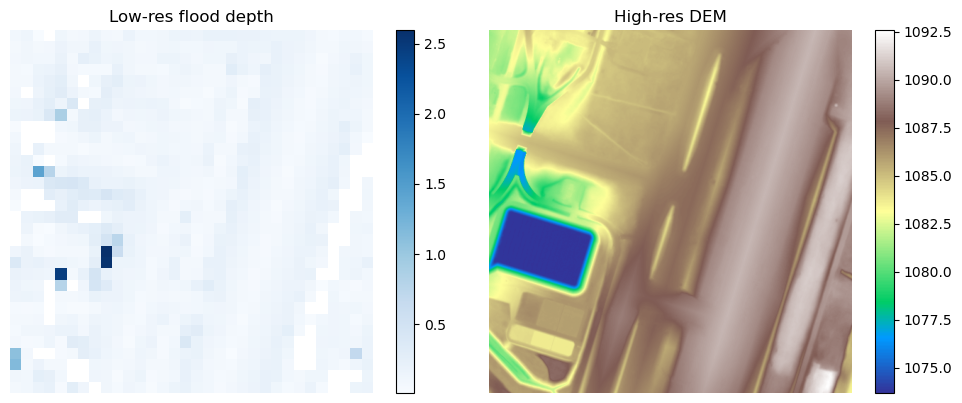

In [10]:
lowres_arr = read_raster_band_1(lowres_fp)
dem_arr = read_raster_band_1(dem_fp)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(np.where(lowres_arr > 0, lowres_arr, np.nan), cmap="Blues")
axes[0].set_title("Low-res flood depth")
fig.colorbar(im0, ax=axes[0])
axes[0].set_axis_off()

im1 = axes[1].imshow(dem_arr, cmap="terrain")
axes[1].set_title("High-res DEM")
fig.colorbar(im1, ax=axes[1])
axes[1].set_axis_off()
fig.tight_layout()


## Run CostGrow

Now run ``tohr`` with the built-in ``CostGrow_Terrain`` model. We set ``--window-method hard`` explicitly so the tutorial reflects the current large-raster-safe CostGrow path.


In [11]:
# HIDDEN (tags:["remove-input"])
# cell below has tag:'remove-output'


In [12]:
!floodsr -q tohr --in lowres032.tif --dem hires002_dem.tif --model-version CostGrow_Terrain --window-method hard --tile-overlap 0 --out lowres032_costgrow_sr.tif


/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_4-zKgTnq/run/lowres032_costgrow_sr.tif


In [13]:
# HIDDEN (tags:["remove-input"])
assert costgrow_fp.is_file(), f"missing CostGrow output\n    {costgrow_fp}"


## Run the ResUNet baseline

Next run the learned ``ResUNet_16x_DEM`` model on the same inputs so we can compare the two outputs directly.


In [14]:
# HIDDEN (tags:["remove-input"])
# cell below has tag:'remove-output'


In [15]:
!floodsr -q tohr --in lowres032.tif --dem hires002_dem.tif --model-version ResUNet_16x_DEM --out lowres032_resunet_sr.tif


feather pass:   0%|                                   | 0/1 [00:00<?, ?window/s]

final write pass:   0%|                              | 0/128 [00:00<?, ?block/s]

final write pass: 100%|██████████████████| 128/128 [00:00<00:00, 9015.31block/s]
/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_4-zKgTnq/run/lowres032_resunet_sr.tif


In [16]:
# HIDDEN (tags:["remove-input"])
assert resunet_fp.is_file(), f"missing ResUNet output\n    {resunet_fp}"


## Write a comparison raster

For a quick numeric comparison, we save a raster of ``CostGrow - ResUNet`` on the same grid as the model outputs. Positive values indicate deeper predictions from CostGrow, and negative values indicate deeper predictions from ResUNet.


In [17]:
# HIDDEN (tags:["remove-input"])
# cell below has tag:'remove-output'


In [18]:
costgrow_arr = read_raster_band_1(costgrow_fp)
resunet_arr = read_raster_band_1(resunet_fp)
comparison_arr = costgrow_arr - resunet_arr
write_float_raster_like(costgrow_fp, comparison_fp, comparison_arr)
comparison_arr


array([[0.42132255, 0.36114071, 0.27217004, ...,        nan,        nan,
               nan],
       [0.43382666, 0.37724416, 0.30157402, ...,        nan,        nan,
               nan],
       [0.45890129, 0.39657187, 0.31535278, ...,        nan,        nan,
               nan],
       ...,
       [1.35935579, 1.15574653, 0.9156572 , ..., 1.84054174, 1.89771861,
        2.00040143],
       [1.62457284, 1.38010997, 1.13291012, ..., 1.88083753, 1.90448079,
        2.0054999 ],
       [1.8610369 , 1.63089575, 1.36095955, ..., 1.98379037, 1.99846724,
        2.02819824]], shape=(512, 512))

In [19]:
# HIDDEN (tags:["remove-input"])
assert comparison_fp.is_file(), f"missing comparison raster\n    {comparison_fp}"


## Plot the results side by side

The first three panels compare the input and the two high-resolution outputs. The fourth panel shows the signed difference raster so you can quickly spot where the model outputs diverge.


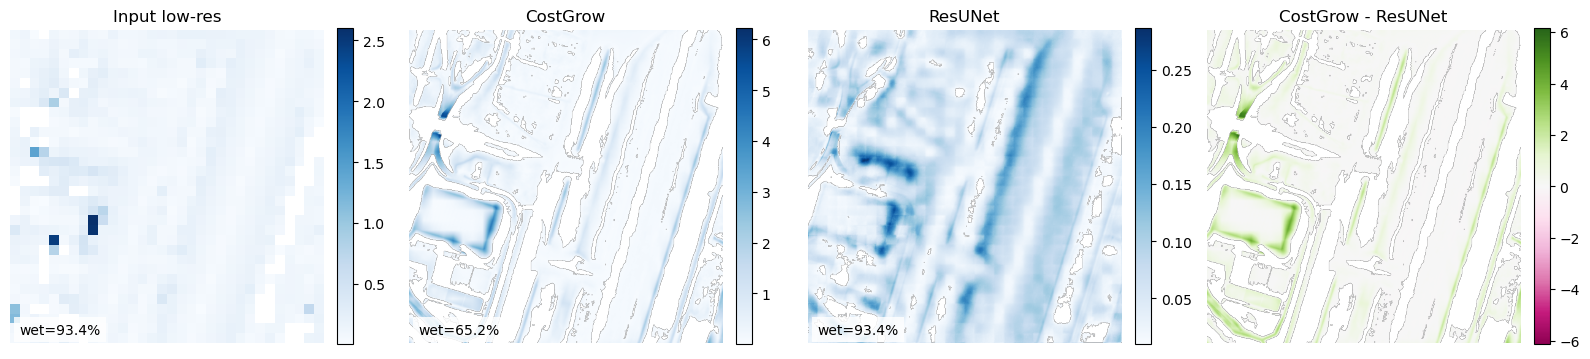

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_l = [
    (axes[0], np.where(lowres_arr > 0, lowres_arr, np.nan), "Input low-res", "Blues"),
    (axes[1], np.where(costgrow_arr > 0, costgrow_arr, np.nan), "CostGrow", "Blues"),
    (axes[2], np.where(resunet_arr > 0, resunet_arr, np.nan), "ResUNet", "Blues"),
]
for ax, arr, title, cmap in plot_l:
    wet_pct = 100.0 * float(np.count_nonzero(np.nan_to_num(arr, nan=0.0) > 0.0)) / float(arr.size)
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    ax.text(0.03, 0.03, f"wet={wet_pct:.1f}%", transform=ax.transAxes, color="black", fontsize=10, bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

delta_vmax = float(np.nanmax(np.abs(comparison_arr)))
if not np.isfinite(delta_vmax) or delta_vmax == 0.0:
    delta_vmax = 1.0
im_delta = axes[3].imshow(comparison_arr, cmap="PiYG", vmin=-delta_vmax, vmax=delta_vmax)
axes[3].set_title("CostGrow - ResUNet")
axes[3].axis("off")
fig.colorbar(im_delta, ax=axes[3], fraction=0.046, pad=0.04)
fig.tight_layout()
